# Module 2: Epidemic Modeling Template

## Team Members:
*Isabella Orlando and Hayden Rue*

## Project Title:
*(Fill in)*

## Project Goal:
This project seeks to... *(what is the purpose of your project -- i.e., describe the question that you seek to answer by analyzing data.)*

## 1. Data and disease background
You can fill out this section throughout the module as you uncover more information about the mystery disease.

By the end of the module (when submitting), you should have some information about each of the following points:
* Prevalence & incidence in the UVA population
* Economic burden (you can generalize from respiratory viruses)
* Symptoms
* Biological mechanisms (anatomy, organ physiology, cell & molecular physiology - you can generalize from viral biology)


## 2. Data Analysis
This section should be filled out sequentially as a full report of the work you've done over this module. You can copy and paste code from any main.py file here, and run it to produce plots. Once you gain more information throughout the module, you do not need to go back and "fix" earlier results. In other words, if your early predictions are found to be wrong when gaining new data, do not go back and rewrite them.

### 2a. Methods

*IN A SUMMARY, DESCRIBE THE METHODS YOU USED TO ANALYZE AND MODEL THE DATA.*


<div style="
    border-left: 6px solid #fbc02d;
    background-color: #fff8e1;
    padding: 10px 15px;
    border-radius: 4px;
">
<b style="color:#f57f17;">ANALYSIS AFTER DATA RELEASE #1</b> 

</div>



### 2b. Plot the data & estimate initial growth rate (R0) from early data (through day 45)
This section should come from your python code after Data Release #1.

In [1]:
#%%
import pandas as pd
import matplotlib.pyplot as plt

#%%
# Read the data
df = pd.read_csv(r"C:\Users\isabe\OneDrive\Documents\BME2315\Module-2-Epidemics-SIR-Modeling\Data\mystery_virus_daily_active_counts_RELEASE#1.csv", parse_dates=['date'], header=0, index_col=None)

#%%
# Create and label a plot of the active cases over time
plt.figure(figsize=(10, 6))
plt.scatter(df['day'], df['active reported daily cases'])
plt.xlabel('Day')
plt.ylabel('Active Cases')
plt.title('Day vs Active Infections')
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\isabe\\OneDrive\\Documents\\BME2315\\Module-2-Epidemics-SIR-Modeling\\Data\\mystery_virus_daily_active_counts_RELEASE#1.csv'

* The initial number of infections is small but begins to increase rapidly around 25 days. The curve of the graph suggest exponential growth because as the number of infected individuals increases so does the total number of new infections.
* We could measure how quickly the virus is spreading through the growth rate, doubling time, and an average number of people one person can infect to determine how quickly it is spreading
* Knowing how contagious the virus is, population size, presence of immunity, and the length of infectious period, both symptomatic and asymptomatic, will be helpful in determining an outbreak curve.

Estimated r: 0.131365895627797
Estimated I0: 0.7111198627565817
Estimated R0: 1.9286677472085472


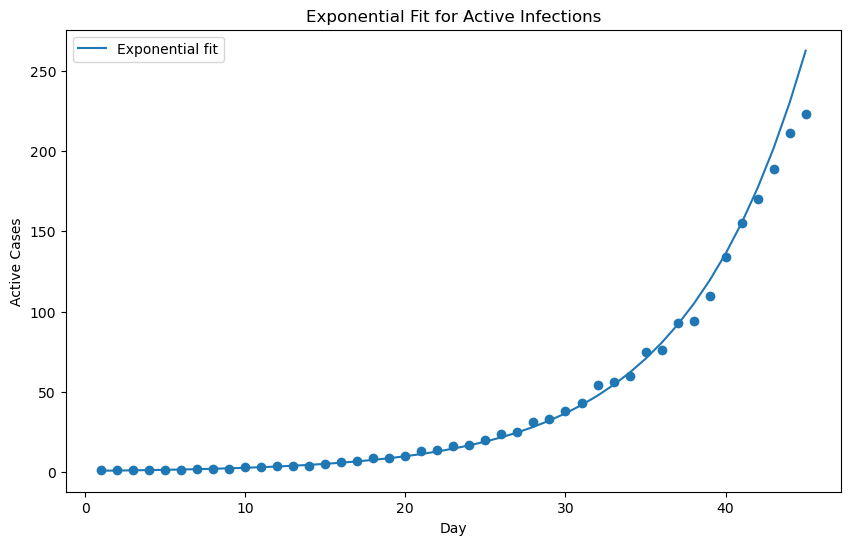

In [ ]:
#%%
import pandas as pd
import matplotlib.pyplot as plt

#%%
# Read the data
df = pd.read_csv(r"/Users/haydenrue/Desktop/Comp BME/Module 2/Module-2-Epidemics-SIR-Modeling/Data/mystery_virus_daily_active_counts_RELEASE#1.csv", parse_dates=['date'], header=0, index_col=None)

import numpy as np

#Get values from variables in csv
t = df["day"].values
I = df["active reported daily cases"].values

#only examine first 45 days for early exponential growth
mask = t <= 45
t_exp = t[mask]
I_exp = I[mask]

#%%
#linearize to use polyfit and get r from slope

# Remove zeros before log
positive_mask = I_exp > 0
t_fit = t_exp[positive_mask]
I_fit = I_exp[positive_mask]

log_I = np.log(I_fit)

# Linear regression
coeffs = np.polyfit(t_fit, log_I, 1)
r = coeffs[0]
log_I0 = coeffs[1]
I0 = np.exp(log_I0)

# print growth rate and estimated initial infections
print("Estimated r:", r)
print("Estimated I0:", I0)

#%%
#Estimate R0

D = 5
R0 = np.exp(r * D)

print("Estimated R0:", R0)


#%%
# Create and label a plot of the active cases over time with exponential fit for growth rate

I_model = I0 * np.exp(r * t)

#Plot
plt.figure(figsize=(10, 6))
plt.scatter(df['day'], df['active reported daily cases'])
plt.plot(t, I_model, label = "Exponential fit")
plt.xlabel('Day')
plt.ylabel('Active Cases')
plt.title('Exponential Fit for Active Infections')
plt.legend()
plt.show()

The estimated R0 from the exponential fit was ~ 1.9287. The R0 estimate value is likely accurate since the data strongly resembles an expoenetial curve.

Ebola and EV-D68 are viruses that have similar R0s around 2.

Ebola is an often fatal virus that results in hemorrhagic illness. It is believed to come from fruit bats with periodic outbreaks present in Central and West Africa.

EV-D68 is a virus that causes respiratory illness, ranging from mild to severe depending on the susceptibility of the person infected. The virus was originally rare, however outbreaks have increased and are showing symptoms related to neurological conditions and muscle weakness


<div style="
    border-left: 6px solid #fbc02d;
    background-color: #fff8e1;
    padding: 10px 15px;
    border-radius: 4px;
">
<b style="color:#f57f17;">ANALYSIS AFTER DATA RELEASE #2</b> 

</div>



### 2c. Use Euler's method to solve the SEIR model.
This section should come from your python code after Data Release #2.

In [ ]:
#%%
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load data from csv file
df = pd.read_csv(r"/Users/haydenrue/Desktop/Comp BME/Module 2/Module-2-Epidemics-SIR-Modeling/Data/mystery_virus_daily_active_counts_RELEASE#2.csv", parse_dates=['date'], header=0, index_col=None)
day = df["day"].values
active = df["active reported daily cases"].values

# Set up variables
N = 17900
S0, E0, I0, R0 = N - 1, 0, 1, 0

# Euler function for SEIR
def run_euler(beta,sigma,gamma,total_days):
    S, E, I, R = [S0], [E0], [I0], [R0] #Initialize S,E,I,R as empty lists; set first item in list equal to initial values
    h = 1 #step size is 1 day

    for t in range(total_days):
        #Calculate derivatives from slide 6 class presentation
        dS = -(beta * S[t]* I[t]) / N
        dE = (beta * S[t] * I[t]) / N - (sigma * E[t])
        dI = (sigma * E[t]) - (gamma * I[t])
        dR = (gamma * I[t])

        #Update values
        S.append(S[t] + dS * h)
        E.append(E[t] + dE * h)
        I.append(I[t] + dI * h)
        R.append(R[t] + dR * h)
    return np.array(I)


### 2d. Fit the SEIR model to the data by changing beta, gamma, and sigma.
This section should come from your python code after Data Release #2.

In [ ]:
# Optimzation (grid search)
# Use estimated R0 to make an estimate for beta and gamma. R0 = 1.93 so beta = 1.93 * gamma
beta_values = np.linspace(0.1,0.5,10) # Transmission rate range 0.1 to 0.5
gamma_values = np.linspace(0.05, 0.2, 10) # Recovery rate 5 to 20 days
sigma_values = np.linspace(0.1, 0.5, 10) # Incubation rate 2 to 10 days

#Grid search to obtain optimal parameters
optimal_sse = np.inf
optimal_beta = None
optimal_sigma = None
optimal_gamma = None

total_days = len(day)

#Find lowest sse by running eulers method for each parameter
for beta in beta_values:
    for sigma in sigma_values:
        for gamma in gamma_values:
            I_model = run_euler(beta, sigma, gamma, total_days)
            I_model = I_model[:len(active)]
            sse = np.sum((active - I_model) **2)

            if sse < optimal_sse:
                optimal_sse = sse
                optimal_beta = beta
                optimal_gamma = gamma
                optimal_sigma = sigma

print("Optimal Beta:", optimal_beta)
print("Optimal Sigma:", optimal_sigma)
print("Optimal Gamma:", optimal_gamma)
print("Optimal SSE:", optimal_sse)

#Run model using new optimal parameters
I_best = run_euler(optimal_beta, optimal_sigma, optimal_gamma, total_days)

### 2e. Plot the model-predicted infections over time compared to the data.
This section should come from your python code after Data Release #2.

Optimal Beta: 0.5
Optimal Sigma: 0.32222222222222224
Optimal Gamma: 0.2
Optimal SSE: 139513.53806278316


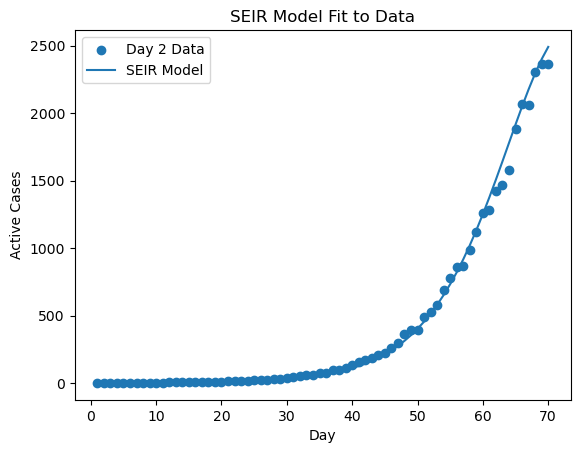

In [ ]:
#%%
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load data from csv file
df = pd.read_csv(r"/Users/haydenrue/Desktop/Comp BME/Module 2/Module-2-Epidemics-SIR-Modeling/Data/mystery_virus_daily_active_counts_RELEASE#2.csv", parse_dates=['date'], header=0, index_col=None)
day = df["day"].values
active = df["active reported daily cases"].values

# Set up variables
N = 17900
S0, E0, I0, R0 = N - 1, 0, 1, 0

# Euler function for SEIR
def run_euler(beta,sigma,gamma,total_days):
    S, E, I, R = [S0], [E0], [I0], [R0] #Initialize S,E,I,R as empty lists; set first item in list equal to initial values
    h = 1 #step size is 1 day

    for t in range(total_days):
        #Calculate derivatives from slide 6 class presentation
        dS = -(beta * S[t]* I[t]) / N
        dE = (beta * S[t] * I[t]) / N - (sigma * E[t])
        dI = (sigma * E[t]) - (gamma * I[t])
        dR = (gamma * I[t])

        #Update values
        S.append(S[t] + dS * h)
        E.append(E[t] + dE * h)
        I.append(I[t] + dI * h)
        R.append(R[t] + dR * h)
    return np.array(I)

# Optimzation (grid search)
# Use estimated R0 to make an estimate for beta and gamma. R0 = 1.93 so beta = 1.93 * gamma
beta_values = np.linspace(0.1,0.5,10) # Transmission rate range 0.1 to 0.5
gamma_values = np.linspace(0.05, 0.2, 10) # Recovery rate 5 to 20 days
sigma_values = np.linspace(0.1, 0.5, 10) # Incubation rate 2 to 10 days

#Grid search to obtain optimal parameters
optimal_sse = np.inf
optimal_beta = None
optimal_sigma = None
optimal_gamma = None

total_days = len(day)

#Find lowest sse by running eulers method for each parameter
for beta in beta_values:
    for sigma in sigma_values:
        for gamma in gamma_values:
            I_model = run_euler(beta, sigma, gamma, total_days)
            I_model = I_model[:len(active)]
            sse = np.sum((active - I_model) **2)

            if sse < optimal_sse:
                optimal_sse = sse
                optimal_beta = beta
                optimal_gamma = gamma
                optimal_sigma = sigma

print("Optimal Beta:", optimal_beta)
print("Optimal Sigma:", optimal_sigma)
print("Optimal Gamma:", optimal_gamma)
print("Optimal SSE:", optimal_sse)

#Run model using new optimal parameters
I_best = run_euler(optimal_beta, optimal_sigma, optimal_gamma, total_days)

#Plot the model vs given data
plt.figure()
plt.scatter(day, active, label ="Day 2 Data")
plt.plot(day, I_best[:len(day)], label ="SEIR Model")
plt.xlabel("Day")
plt.ylabel("Active Cases")
plt.title("SEIR Model Fit to Data")
plt.legend()
plt.show()



### 2e. Predict the day and amount of active cases at the peak of the epidemic spread.
This section should come from your python code after Data Release #2.


Optimal Beta: 0.5
Optimal Sigma: 0.32222222222222224
Optimal Gamma: 0.2
Optimal SSE: 139513.53806278316
Peak infections: 2651.858284444435
Peak occurs on day: 73


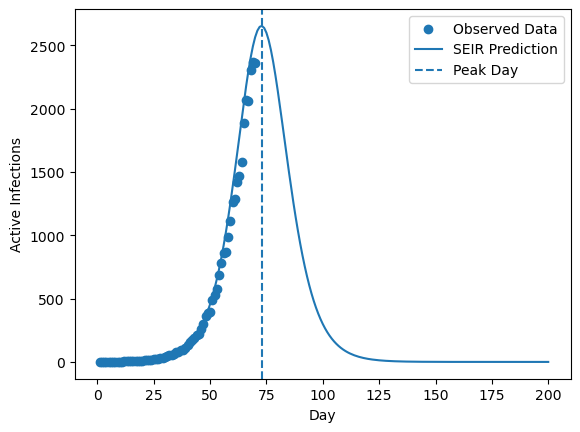

In [ ]:
#%%
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load data from csv file
df = pd.read_csv(r"/Users/haydenrue/Desktop/Comp BME/Module 2/Module-2-Epidemics-SIR-Modeling/Data/mystery_virus_daily_active_counts_RELEASE#2.csv", parse_dates=['date'], header=0, index_col=None)
day = df["day"].values
active = df["active reported daily cases"].values

# Set up variables
N = 17900
S0, E0, I0, R0 = N - 1, 0, 1, 0

# Euler function for SEIR
def run_euler(beta,sigma,gamma,total_days):
    S, E, I, R = [S0], [E0], [I0], [R0] #Initialize S,E,I,R as empty lists; set first item in list equal to initial values
    h = 1 #step size is 1 day

    for t in range(total_days):
        #Calculate derivatives from slide 6 class presentation
        dS = -(beta * S[t]* I[t]) / N
        dE = (beta * S[t] * I[t]) / N - (sigma * E[t])
        dI = (sigma * E[t]) - (gamma * I[t])
        dR = (gamma * I[t])

        #Update values
        S.append(S[t] + dS * h)
        E.append(E[t] + dE * h)
        I.append(I[t] + dI * h)
        R.append(R[t] + dR * h)
    return np.array(I)

# Optimzation (grid search)
# Use estimated R0 to make an estimate for beta and gamma. R0 = 1.93 so beta = 1.93 * gamma
beta_values = np.linspace(0.1,0.5,10) # Transmission rate range 0.1 to 0.5
gamma_values = np.linspace(0.05, 0.2, 10) # Recovery rate 5 to 20 days
sigma_values = np.linspace(0.1, 0.5, 10) # Incubation rate 2 to 10 days

#Grid search to obtain optimal parameters
optimal_sse = np.inf
optimal_beta = None
optimal_sigma = None
optimal_gamma = None

total_days = len(day)

#Find lowest sse by running eulers method for each parameter
for beta in beta_values:
    for sigma in sigma_values:
        for gamma in gamma_values:
            I_model = run_euler(beta, sigma, gamma, total_days)
            I_model = I_model[:len(active)]
            sse = np.sum((active - I_model) **2)

            if sse < optimal_sse:
                optimal_sse = sse
                optimal_beta = beta
                optimal_gamma = gamma
                optimal_sigma = sigma

print("Optimal Beta:", optimal_beta)
print("Optimal Sigma:", optimal_sigma)
print("Optimal Gamma:", optimal_gamma)
print("Optimal SSE:", optimal_sse)

#Run model using new optimal parameters
I_best = run_euler(optimal_beta, optimal_sigma, optimal_gamma, total_days)

#Predict future trends
future_days = 200

#Run eulers method on future days and find peak infections and peak day
I_future = run_euler(optimal_beta, optimal_sigma, optimal_gamma, future_days)
peak_infections = np.max(I_future)
peak_day = np.argmax(I_future)
print("Peak infections:", peak_infections)
print("Peak occurs on day:", peak_day)

plt.figure()
plt.scatter(day, active, label="Observed Data")
plt.plot(range(len(I_future)), I_future, label="SEIR Prediction")
plt.axvline(peak_day, linestyle="--", label="Peak Day")
plt.xlabel("Day")
plt.ylabel("Active Infections")
plt.legend()
plt.show()

The peak number of active infections(2,652) occuring at day 73 is a resonable prediction considering the large population size of 17,900. This means about 15% of the population is infected on the peak, or 73rd day.


<div style="
    border-left: 6px solid #fbc02d;
    background-color: #fff8e1;
    padding: 10px 15px;
    border-radius: 4px;
">
<b style="color:#f57f17;">ANALYSIS AFTER DATA RELEASE #3</b> 

</div>



### 2f. Plot the full dataset (Data Release #3) against your model.
This section should come from your python code after Data Release #3.


Our model shows ~12% relative error from the new data release(true values) for the day of peak cases and ~19.5% for the number of peak cases.

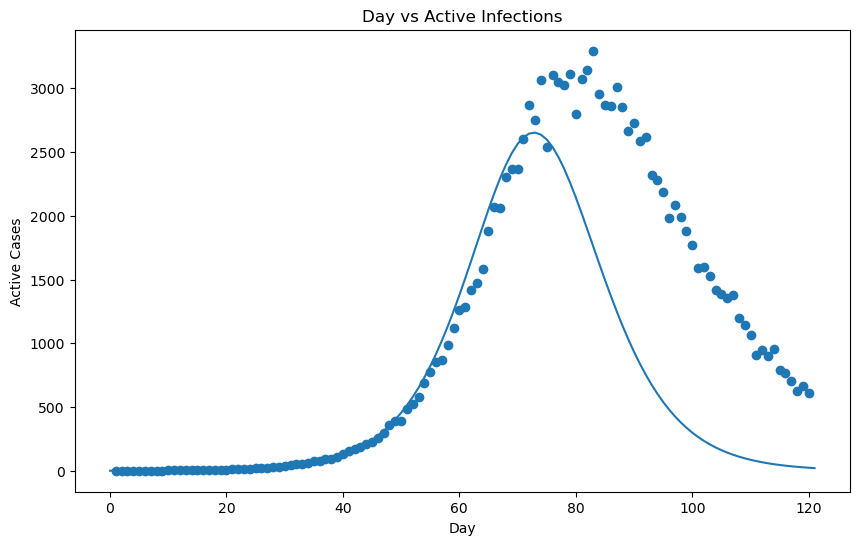

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

days = 121
N = 17900
S0, E0, I0, R0 = N - 1, 0, 1, 0

# Load data from csv file
#df = pd.read_csv(r"/Users/haydenrue/Desktop/Comp BME/Module 2/Module-2-Epidemics-SIR-Modeling/Data/mystery_virus_daily_active_counts_RELEASE#2.csv", parse_dates=['date'], header=0, index_col=None)
df = pd.read_csv(r"/Users/haydenrue/Desktop/Comp BME/Module 2/Module-2-Epidemics-SIR-Modeling/Data/mystery_virus_daily_active_counts_RELEASE#3.csv")
day = df["day"].values
active = df["active reported daily cases"].values

def run_euler(beta,sigma,gamma,total_days):
    S, E, I, R = [S0], [E0], [I0], [R0] #Initialize S,E,I,R as empty lists; set first item in list equal to initial values
    h = 1 #step size is 1 day

    for t in range(total_days):
        #Calculate derivatives from slide 6 class presentation
        dS = -(beta * S[t]* I[t]) / N
        dE = (beta * S[t] * I[t]) / N - (sigma * E[t])
        dI = (sigma * E[t]) - (gamma * I[t])
        dR = (gamma * I[t])

        #Update values
        S.append(S[t] + dS * h)
        E.append(E[t] + dE * h)
        I.append(I[t] + dI * h)
        R.append(R[t] + dR * h)
    return np.array(I)


optimal_beta = .5
optimal_gamma = .2
optimal_sigma = .32222222222

I_future = run_euler(optimal_beta, optimal_sigma, optimal_gamma, days)

plt.figure(figsize=(10, 6))
plt.scatter(df['day'], df['active reported daily cases'])
plt.plot(range(len(I_future)), I_future, label="SEIR Prediction")
plt.xlabel('Day')
plt.ylabel('Active Cases')
plt.title('Day vs Active Infections')
plt.show()

### 2g. Intervention strategies for new outbreak at VT (70 days of infection)
This section should come from your python code after Data Release #3.



## Verify and validate your analysis: 

*(Describe how you checked to see that your analysis gave you an answer that you believe (verify). Describe how your determined if your analysis gave you an answer that is supported by other evidence (e.g., a published paper).*

## Conclusions and Ethical Implications: 
*(Think about the answer your analysis generated, draw conclusions related to your overarching question, and discuss the ethical implications of your conclusions.*

## Limitations and Future Work: 
*(Think about the answer your analysis generated, draw conclusions related to your overarching question, and discuss the ethical implications of your conclusions.*